## 1. Load and merge

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu

# Notebook is in src/, so ../results/figures points to project_root/results/figures
fig_dir = Path("../results/figures")
fig_dir.mkdir(parents=True, exist_ok=True)

base = pd.read_csv("featureDf_baseline.csv")
meta = pd.read_csv("../data/new_metadata.csv")

df = base[['img_id', 'border']].merge(meta[['img_id', 'diagnostic']], on='img_id', how='left')

cancer_classes = ['BCC', 'MEL', 'SCC']
df['label'] = df['diagnostic'].isin(cancer_classes).astype(int)
df['class'] = df['label'].map({0: 'Benign', 1: 'Malignant'})

print(df.shape)
df.head()

(1945, 5)


,img_id,border,diagnostic,label,class
0,PAT_1516_1765_530.png,0.776982,NEV,0,Benign
1,PAT_46_881_939.png,0.579152,BCC,1,Malignant
2,PAT_1545_1867_547.png,0.625163,ACK,0,Benign
3,PAT_1989_4061_934.png,0.779322,ACK,0,Benign
4,PAT_684_1302_588.png,0.832370,BCC,1,Malignant


## 2. Basic statistics

In [2]:
print(df['border'].describe())
print()
print(df.groupby('class')['border'].describe())

count    1945.000000
mean        0.734696
std         0.139172
min         0.074760
25%         0.670230
50%         0.776089
75%         0.839746
max         0.904025
Name: border, dtype: float64

            count      mean       std       min       25%       50%       75%  \
class                                                                           
Benign      925.0  0.741439  0.136818  0.074760  0.690748  0.782400  0.840236   
Malignant  1020.0  0.728582  0.141061  0.108193  0.656846  0.769495  0.838261   

                max  
class                
Benign     0.904025  
Malignant  0.897380  


## 3. Distribution plot

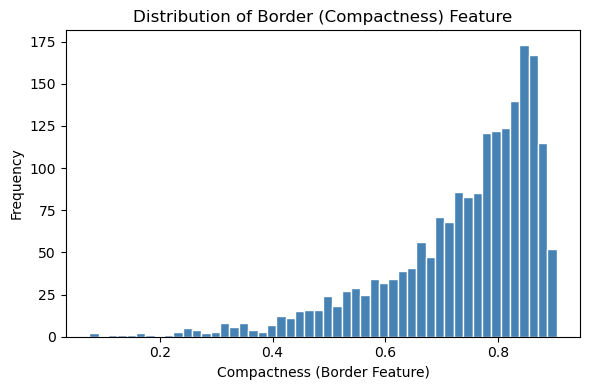

In [3]:
plt.figure(figsize=(6, 4))
plt.hist(df['border'].dropna(), bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Compactness (Border Feature)')
plt.ylabel('Frequency')
plt.title('Distribution of Border (Compactness) Feature')
plt.tight_layout()
plt.savefig(fig_dir / 'border_distribution.png', dpi=300)
plt.show()

## 4. Benign vs malignant — KDE

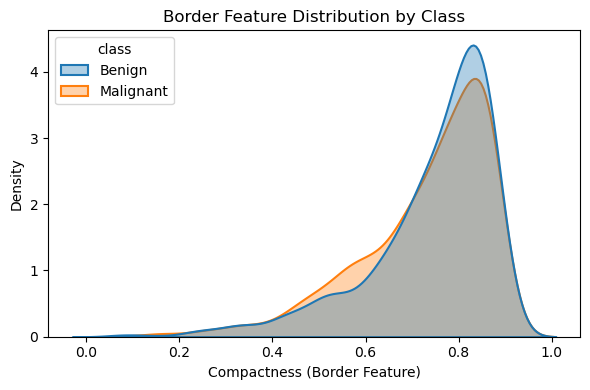

In [4]:
df_plot = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['border', 'class'])

plt.figure(figsize=(6, 4))
sns.kdeplot(data=df_plot, x='border', hue='class', fill=True,
            common_norm=False, alpha=0.35, linewidth=1.5)
plt.xlabel('Compactness (Border Feature)')
plt.ylabel('Density')
plt.title('Border Feature Distribution by Class')
plt.tight_layout()
plt.savefig(fig_dir / 'border_by_class.png', dpi=300)
plt.show()

## 5. Boxplot

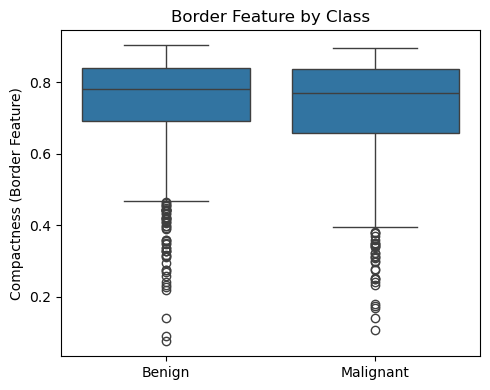

In [5]:
plt.figure(figsize=(5, 4))
sns.boxplot(data=df_plot, x='class', y='border', order=['Benign', 'Malignant'])
plt.xlabel('')
plt.ylabel('Compactness (Border Feature)')
plt.title('Border Feature by Class')
plt.tight_layout()
plt.savefig(fig_dir / 'border_boxplot.png', dpi=300)
plt.show()

## 6. Statistical test — Welch's t-test

In [6]:
benign    = df_plot.loc[df_plot['label'] == 0, 'border'].dropna()
malignant = df_plot.loc[df_plot['label'] == 1, 'border'].dropna()

mean_benign    = benign.mean()
mean_malignant = malignant.mean()
mean_diff      = mean_malignant - mean_benign

t_stat, p_value = ttest_ind(malignant, benign, equal_var=False)

pooled_std = np.sqrt((benign.std()**2 + malignant.std()**2) / 2)
cohen_d    = mean_diff / pooled_std if pooled_std != 0 else np.nan

result = pd.DataFrame([{
    'feature':          'border',
    'benign_mean':      round(mean_benign,    4),
    'malignant_mean':   round(mean_malignant, 4),
    'mean_difference':  round(mean_diff,      4),
    't_statistic':      round(t_stat,         4),
    'p_value':          p_value,
    'cohen_d':          round(cohen_d,        4),
}])

display(result)
print()
if p_value < 0.05:
    direction = "lower" if mean_diff < 0 else "higher"
    print(f"Significant (p = {p_value:.4e}): malignant lesions have {direction} compactness.")
else:
    print(f"Not significant (p = {p_value:.4f}).")

,feature,benign_mean,malignant_mean,mean_difference,t_statistic,p_value,cohen_d
0,border,0.7414,0.7286,-0.0129,-2.0394,0.041545,-0.0925



Significant (p = 4.1545e-02): malignant lesions have lower compactness.


## Interpretation

- **Compactness ≈ 1** → near-perfect circle (smooth, rounded lesion — typically benign)
- **Compactness < 1** → irregular, jagged boundary (typically malignant)
- **mean_difference < 0** → malignant lesions have lower compactness on average
- **p_value < 0.05** → the difference between classes is statistically significant
- **cohen_d** → effect size; |d| > 0.2 small, > 0.5 medium, > 0.8 large

## 7. Mann-Whitney U test (non-parametric alternative)

In [7]:
stat, p_mw = mannwhitneyu(benign, malignant, alternative='two-sided')
print(f"Mann-Whitney U statistic: {stat:.1f}")
print(f"p-value: {p_mw:.4e}")

Mann-Whitney U statistic: 496877.0
p-value: 4.2222e-02


## 8. Correlation with label

In [8]:
corr = df_plot[['border', 'label']].corr()
print(corr)
print()
print(f"Pearson r (border vs label): {corr.loc['border','label']:.4f}")

          border     label
border  1.000000 -0.046148
label  -0.046148  1.000000

Pearson r (border vs label): -0.0461
